In [1]:
%pip install -q --no-warn-conflicts malariagen_data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 104.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.1/216.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/71.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.9/775.9 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.

In [2]:
import malariagen_data

In [3]:
import pandas as pd
import numpy as np
import allel
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [4]:
import plotly.io as pio
pio.renderers.default = "notebook+colab"

In [5]:
ag3 = malariagen_data.Ag3()
ag3

<MalariaGEN Ag3 API client>
Storage URL                           : gs://vo_agam_release_master_us_central1/
Data releases available               : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
Results cache                         : None
Cohorts analysis                      : 20250815
AIM analysis                          : 20220528
Site filters analysis                 : dt_20200416
Software version                      : malariagen_data 15.5.0
Client location                       : District of Columbia, United States (Google Cloud us-other)
Data filtered to unrestricted use only: False
Data filtered to surveillance use only: False
Relevant data releases                : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
---
Please note that data are subject to terms of use,
for more information see https://www.malariagen.net/data
or contact support@malariagen.net. For API documentation see 
https://malariagen.github.io/malariagen-data-python/v15.5.0/Ag3.html

## Extract haplotypes from the region of interest

In [6]:
vgsc_haps = ag3.haplotypes(region="2L: 2,320,000 - 2,450,000",
                           sample_sets="3.0")

In [ ]:
vgsc_haps

<xarray.Dataset> Size: 80MB
Dimensions:           (variants: 14363, alleles: 2, samples: 2784, ploidy: 2)
Coordinates:
    variant_position  (variants) int32 57kB dask.array<chunksize=(14363,), meta=np.ndarray>
    variant_contig    (variants) uint8 14kB dask.array<chunksize=(14363,), meta=np.ndarray>
    sample_id         (samples) object 22kB dask.array<chunksize=(81,), meta=np.ndarray>
Dimensions without coordinates: variants, alleles, samples, ploidy
Data variables:
    variant_allele    (variants, alleles) |S1 29kB dask.array<chunksize=(14363, 1), meta=np.ndarray>
    call_genotype     (variants, samples, ploidy) int8 80MB dask.array<chunksize=(14363, 64, 2), meta=np.ndarray>
Attributes:
    contigs:   ('2R', '2L', '3R', '3L', 'X')
    analysis:  gamb_colu_arab

## Extract the variant positions

In [7]:
pos = allel.SortedIndex(sorted(vgsc_haps["variant_position"].values))
pos.shape

(14363,)

## Extract the haplotype itself

In [8]:
gt = vgsc_haps["call_genotype"].values

In [ ]:
gt.shape

(14363, 2784, 2)

In [ ]:
gt

array([[[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       ...,

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]]], dtype=int8)

## Reshape the genotype to a two-dimensional data

In [9]:
ht = gt.reshape(gt.shape[0], -1)

In [ ]:
ht.shape

(14363, 5568)

## Convert to a Haplotype Array

In [10]:
haps = allel.HaplotypeArray(ht)

In [ ]:
haps.shape

(9460, 5568)

In [ ]:
haps

<HaplotypeArray shape=(14363, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

In [ ]:
pos

0,1,2,3,4,...,14358,14359,14360,14361,14362
np.int32(2320960),np.int32(2320963),np.int32(2320966),np.int32(2321009),np.int32(2321050),...,np.int32(2448010),np.int32(2448013),np.int32(2448014),np.int32(2448017),np.int32(2448022)


## Define the Transcript and the Cohort to work with

In [11]:
transcript = "AGAP004707-RD"

In [12]:
cohorts = "country"

## Call the SNPs in that transcript

In [13]:
variants = ag3.snp_allele_frequencies(transcript= transcript,
                                      cohorts= cohorts,
                                      sample_sets = '3.0',
                                      drop_invariant=False,
)
variants

Load SNP genotypes:   0%|          | 0/297 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/20 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/209001 [00:00<?, ?it/s]

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
2L     2358158  A          C          M1L                       True   
                           T          M1L                       True   
                           G          M1V                       True   
       2358159  T          A          M1K                       True   
                           C          M1T                       True   
...                                                              ...   
       2431616  G          C          *2119S                    True   
                           T          *2119L                    True   
       2431617  A          C          *2119C                    True   
                           T          *2119C                    True   
                           G          *2119W                    True   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
2L     2358158  A          C          M1L                  True       True   
                           T          M1L                  True       True   
                           G          M1V                  True       True   
       2358159  T          A          M1K                  True       True   
                           C          M1T                  True       True   
...                                                         ...        ...   
       2431616  G          C          *2119S               True       True   
                           T          *2119L               True       True   
       2431617  A          C          *2119C               True       True   
                           T          *2119C               True       True   
                           G          *2119W               True       True   

                                                 frq_Angola  frq_Burkina Faso  \
contig position ref_allele alt_allele aa_change                                 
2L     2358158  A          C          M1L               0.0               0.0   
                           T          M1L               0.0               0.0   
                           G          M1V               0.0               0.0   
       2358159  T          A          M1K               0.0               0.0   
                           C          M1T               0.0               0.0   
...                                                     ...               ...   
       2431616  G          C          *2119S            0.0               0.0   
                           T          *2119L            0.0               0.0   
       2431617  A          C          *2119C            0.0               0.0   
                           T          *2119C            0.0               0.0   
                           G          *2119W            0.0               0.0   

                                                 frq_Cameroon  \
contig position ref_allele alt_allele aa_change                 
2L     2358158  A          C          M1L                 0.0   
                           T          M1L                 0.0   
                           G          M1V                 0.0   
       2358159  T          A          M1K                 0.0   
                           C          M1T                 0.0   
...                                                       ...   
       2431616  G          C          *2119S              0.0   
                           T          *2119L              0.0   
       2431617  A          C          *2119C              0.0   
                           T          *2119C              0.0   
                           G          *2119W              0.0   

                                                 frq_Central African Republic  \
contig position ref_allele alt_allele aa_change                                 
2L     2358158  A          C       

## Group such that only nsSNPs that occur at least once at a frequency of 0.05 in any cohort is extracted

In [14]:
missense_variants = variants.query("effect == 'NON_SYNONYMOUS_CODING' and max_af >= 0.05")
missense_variants

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
2L     2390177  G          A          R254K                     True   
       2391228  G          C          V402L                     True   
       2399997  G          C          D466H                     True   
       2400071  G          A          M490I                     True   
       2402466  G          T          G531V                     True   
       2407769  C          T          A656V                     True   
       2407954  A          G          I693V                    False   
       2407967  A          C          Q697P                    False   
       2408113  G          A          R720Q                    False   
       2408124  G          T          A724S                    False   
       2416877  A          T          M757L                     True   
       2416980  C          T          T791M                     True   
       2422651  T          C          L995S                     True   
       2422652  A          T          L995F                     True   
       2424384  C          T          A1125V                    True   
       2429617  T          C          I1527T                    True   
       2429745  A          T          N1570Y                    True   
       2429897  A          G          E1597G                    True   
       2430106  T          A          L1667M                    True   
       2430424  G          T          A1746S                   False   
       2430817  G          A          V1853I                    True   
       2430863  T          C          I1868T                    True   
       2430880  C          T          P1874S                    True   
       2430881  C          T          P1874L                    True   
       2431061  C          T          A1934V                    True   
       2431079  T          C          I1940T                    True   
       2431390  A          G          T2044A                    True   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
2L     2390177  G          A          R254K                True       True   
       2391228  G          C          V402L                True       True   
       2399997  G          C          D466H                True       True   
       2400071  G          A          M490I                True       True   
       2402466  G          T          G531V                True       True   
       2407769  C          T          A656V                True       True   
       2407954  A          G          I693V               False      False   
       2407967  A          C          Q697P               False       True   
       2408113  G          A          R720Q               False      False   
       2408124  G          T          A724S               False      False   
       2416877  A          T          M757L                True       True   
       2416980  C          T          T791M                True       True   
       2422651  T          C          L995S                True       True   
       2422652  A          T          L995F                True       True   
       2424384  C          T          A1125V               True       True   
       2429617  T          C          I1527T               True       True   
       2429745  A          T          N1570Y               True       True   
       2429897  A          G          E1597G               True       True   
       2430106  T          A          L1667M               True       True   
       2430424  G          T          A1746S               True      False   
       2430817  G          A          V1853I               True       True   
       2430863  T          C          I1868T               True       True   
       2430880  C          T          P1874S               True       True   
       243

## Extract the indexes

In [15]:
vgsc_index = missense_variants[[]]
vgsc_index


Empty DataFrame
Columns: []
Index: [(2L, 2390177, G, A, R254K), (2L, 2391228, G, C, V402L), (2L, 2399997, G, C, D466H), (2L, 2400071, G, A, M490I), (2L, 2402466, G, T, G531V), (2L, 2407769, C, T, A656V), (2L, 2407954, A, G, I693V), (2L, 2407967, A, C, Q697P), (2L, 2408113, G, A, R720Q), (2L, 2408124, G, T, A724S), (2L, 2416877, A, T, M757L), (2L, 2416980, C, T, T791M), (2L, 2422651, T, C, L995S), (2L, 2422652, A, T, L995F), (2L, 2424384, C, T, A1125V), (2L, 2429617, T, C, I1527T), (2L, 2429745, A, T, N1570Y), (2L, 2429897, A, G, E1597G), (2L, 2430106, T, A, L1667M), (2L, 2430424, G, T, A1746S), (2L, 2430817, G, A, V1853I), (2L, 2430863, T, C, I1868T), (2L, 2430880, C, T, P1874S), (2L, 2430881, C, T, P1874L), (2L, 2431061, C, T, A1934V), (2L, 2431079, T, C, I1940T), (2L, 2431390, A, G, T2044A)]

## Conver the object to a dataframe

In [16]:
vgsc_df = pd.DataFrame(list(vgsc_index.index), columns=[
    "contig", "position", "ref_allele", "alt_allele", "aa_change"
])
vgsc_df

,contig,position,ref_allele,alt_allele,aa_change
0,2L,2390177,G,A,R254K
1,2L,2391228,G,C,V402L
2,2L,2399997,G,C,D466H
3,2L,2400071,G,A,M490I
4,2L,2402466,G,T,G531V
5,2L,2407769,C,T,A656V
6,2L,2407954,A,G,I693V
7,2L,2407967,A,C,Q697P
8,2L,2408113,G,A,R720Q
9,2L,2408124,G,T,A724S


## Sort the positions of the selected variants

In [17]:
pos_selected = allel.SortedIndex(sorted(vgsc_df['position']))

In [18]:
pos_selected

0,1,2,3,4,...,22,23,24,25,26
np.int64(2390177),np.int64(2391228),np.int64(2399997),np.int64(2400071),np.int64(2402466),...,np.int64(2430880),np.int64(2430881),np.int64(2431061),np.int64(2431079),np.int64(2431390)


## Use that file to locate the keys of the positions in the main position file. Set the strict parameter to ensure that only the present positions are called, else it will create an error.

In [19]:
loc_selected = pos.locate_keys(pos_selected, strict= False)
loc_selected

array([False, False, False, ..., False, False, False])

## Use said file to select the haplotypes corresponding to the selected positions

In [33]:
haps_selected = haps[loc_selected]
haps_selected

<HaplotypeArray shape=(18, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

## Define a function that checks the position in pos_selected that are not found in pos so they can be easily removed

In [24]:
def get_missing_values(idx1, idx2):
    missing_values = []
    for i in idx1:
        if i not in idx2:
            missing_values.append(i)
    return missing_values

In [28]:
values_to_remove = get_missing_values(pos_selected, pos)

[np.int64(2391228),
 np.int64(2400071),
 np.int64(2407954),
 np.int64(2407967),
 np.int64(2408113),
 np.int64(2408124),
 np.int64(2424384),
 np.int64(2430424),
 np.int64(2431061)]

## this creates a dataframe that holds the mutations whose haplotypes are present.

In [29]:
vgsc_df2 = vgsc_df[~vgsc_df["position"].isin(values_to_remove)]
vgsc_df2

,contig,position,ref_allele,alt_allele,aa_change
0,2L,2390177,G,A,R254K
2,2L,2399997,G,C,D466H
4,2L,2402466,G,T,G531V
5,2L,2407769,C,T,A656V
10,2L,2416877,A,T,M757L
11,2L,2416980,C,T,T791M
12,2L,2422651,T,C,L995S
13,2L,2422652,A,T,L995F
15,2L,2429617,T,C,I1527T
16,2L,2429745,A,T,N1570Y


## this creates a dataframe to show which mutations were not present and were subsequently removed

In [31]:
vgsc_mut = vgsc_df[vgsc_df["position"].isin(values_to_remove)]
vgsc_mut

,contig,position,ref_allele,alt_allele,aa_change
1,2L,2391228,G,C,V402L
3,2L,2400071,G,A,M490I
6,2L,2407954,A,G,I693V
7,2L,2407967,A,C,Q697P
8,2L,2408113,G,A,R720Q
9,2L,2408124,G,T,A724S
14,2L,2424384,C,T,A1125V
19,2L,2430424,G,T,A1746S
24,2L,2431061,C,T,A1934V


In [ ]:
ac = haps_selected.count_alleles()
ac.displayall()

,0,1
0,5220,348
1,5500,68
2,5565,3
3,5556,12
4,5565,3
5,5373,195
6,4729,839
7,3395,2173
8,5475,93
9,5263,305


## Define the function to compute the Lenwontin D'

In [30]:
def lewontin_d_prime(h, i, j, a=1, b=1):
    """
    h = haplotype matrix (SNPs × haplotypes)
    i = index of SNP1
    j = index of SNP2
    a = derived allele at SNP1
    b = derived allele at SNP2
    """
    n_a = n_b = 0
    n_ab = 0
    n = 0

    for k in range(h.shape[1]):
        allele_i = h[i, k]
        allele_j = h[j, k]
        if allele_i < 0 or allele_j < 0:
            continue

        if allele_i == a:
            n_a += 1
        if allele_j == b:
            n_b += 1
        if allele_i == a and allele_j == b:
            n_ab += 1
        n += 1

    if n == 0 or n_a == 0 or n_b == 0 or n == n_a or n == n_b:
        return np.nan

    D = (n * n_ab) - (n_a * n_b)

    if D >= 0:
        Dmax = min(n_a * (n - n_b), (n - n_a) * n_b)
    else:
        Dmax = min(n_a * n_b, (n - n_a) * (n - n_b))

    return D / Dmax

## Create the pairwise matrix

In [34]:
n = haps_selected.shape[0]
ld_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        dprime = lewontin_d_prime(haps_selected, i, j, 1, 1)
        ld_matrix[i, j] = dprime
        ld_matrix[j, i] = dprime

## create a new column that combines all the information in your dataframe

In [35]:
vgsc_df2["label"] = (
    vgsc_df2["position"].astype(str)
    + ": "
    + vgsc_df2["ref_allele"].astype(str)
    + ">"
    + vgsc_df2["alt_allele"].astype(str)
    + " "
    + vgsc_df2["aa_change"]
)
vgsc_df2

/tmp/ipython-input-3515544718.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,contig,position,ref_allele,alt_allele,aa_change,label
0,2L,2390177,G,A,R254K,2390177: G>A R254K
2,2L,2399997,G,C,D466H,2399997: G>C D466H
4,2L,2402466,G,T,G531V,2402466: G>T G531V
5,2L,2407769,C,T,A656V,2407769: C>T A656V
10,2L,2416877,A,T,M757L,2416877: A>T M757L
11,2L,2416980,C,T,T791M,2416980: C>T T791M
12,2L,2422651,T,C,L995S,2422651: T>C L995S
13,2L,2422652,A,T,L995F,2422652: A>T L995F
15,2L,2429617,T,C,I1527T,2429617: T>C I1527T
16,2L,2429745,A,T,N1570Y,2429745: A>T N1570Y


## create an array of your labels to be used

In [36]:
labels = vgsc_df2["label"].to_numpy()

In [37]:
ld_df = pd.DataFrame(ld_matrix, index=labels, columns=labels)

In [ ]:
ld_df

,2390177: G>A R254K,2399997: G>C D466H,2402466: G>T G531V,2407769: C>T A656V,2416877: A>T M757L,2416980: C>T T791M,2422651: T>C L995S,2422652: A>T L995F,2429617: T>C I1527T,2429745: A>T N1570Y,2429897: A>G E1597G,2430106: T>A L1667M,2430817: G>A V1853I,2430863: T>C I1868T,2430880: C>T P1874S,2430881: C>T P1874L,2431079: T>C I1940T,2431390: A>G T2044A
2390177: G>A R254K,0.000000,-0.764706,-1.000000,-1.0,-1.0,-1.000000,-0.923719,0.976436,-1.000000,-0.947541,-1.0,-1.000000,-1.0,-1.0,-1.000000,-1.0,-0.166667,-1.0
2399997: G>C D466H,-0.764706,0.000000,-1.000000,-1.0,-1.0,-1.000000,-0.902405,0.975881,-1.000000,-1.000000,-1.0,-1.000000,-1.0,-1.0,-1.000000,-1.0,0.895253,-1.0
2402466: G>T G531V,-1.000000,-1.000000,0.000000,-1.0,-1.0,-1.000000,0.607528,-1.000000,-1.000000,-1.000000,-1.0,-1.000000,-1.0,-1.0,-1.000000,-1.0,-1.000000,-1.0
2407769: C>T A656V,-1.000000,-1.000000,-1.000000,0.0,-1.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.000000,-1.0,-1.0,-1.000000,-1.0,-1.000000,-1.0
2416877: A>T M757L,-1.000000,-1.000000,-1.000000,-1.0,0.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.000000,-1.0,-1.0,-1.000000,-1.0,-1.000000,-1.0
2416980: C>T T791M,-1.000000,-1.000000,-1.000000,-1.0,-1.0,0.000000,-1.000000,1.000000,-1.000000,-1.000000,-1.0,-1.000000,-1.0,-1.0,-0.790045,-1.0,-1.000000,-1.0
2422651: T>C L995S,-0.923719,-0.902405,0.607528,-1.0,-1.0,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.000000,-1.0,-1.0,-1.000000,-1.0,-1.000000,-1.0
2422652: A>T L995F,0.976436,0.975881,-1.000000,-1.0,-1.0,1.000000,-1.000000,0.000000,-1.000000,0.994623,1.0,0.965832,1.0,1.0,1.000000,1.0,1.000000,-1.0
2429617: T>C I1527T,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,-1.0,-0.376344,-1.0,-1.0,-1.000000,-1.0,-1.000000,-1.0
2429745: A>T N1570Y,-0.947541,-1.000000,-1.000000,-1.0,-1.0,-1.000000,-1.000000,0.994623,-1.000000,0.000000,-1.0,-1.000000,-1.0,-1.0,-1.000000,-1.0,-1.000000,-1.0


## Plotting the heatmap

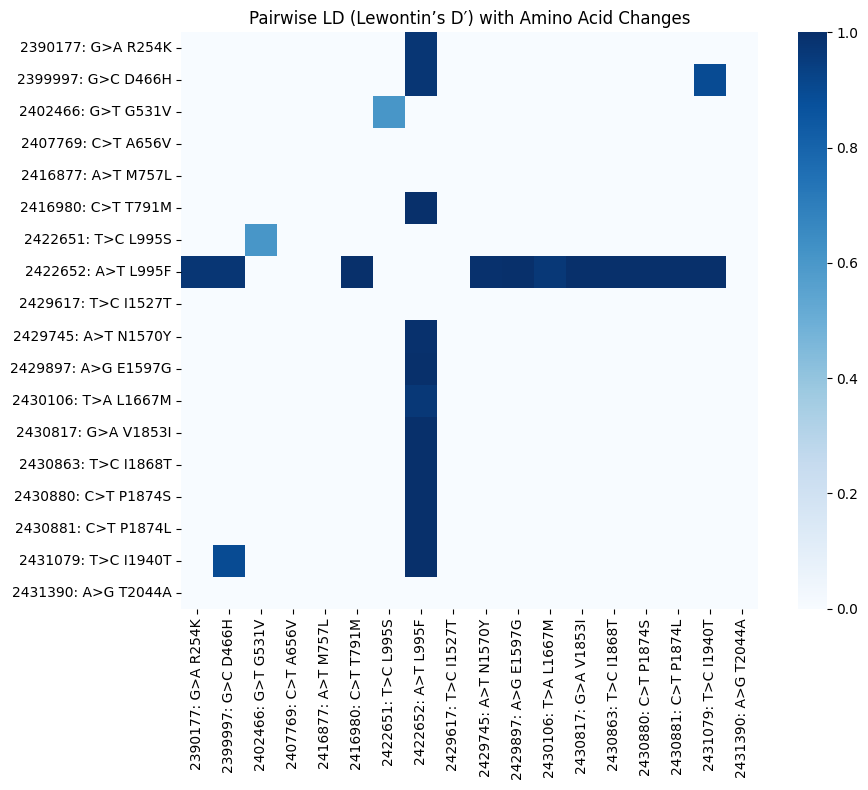

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(ld_df, cmap="Blues", vmin=0, vmax=1, square=True,
            xticklabels=True, yticklabels=True)

plt.title("Pairwise LD (Lewontin’s D′) with Amino Acid Changes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##define a function that plots your heatmap with gridspace

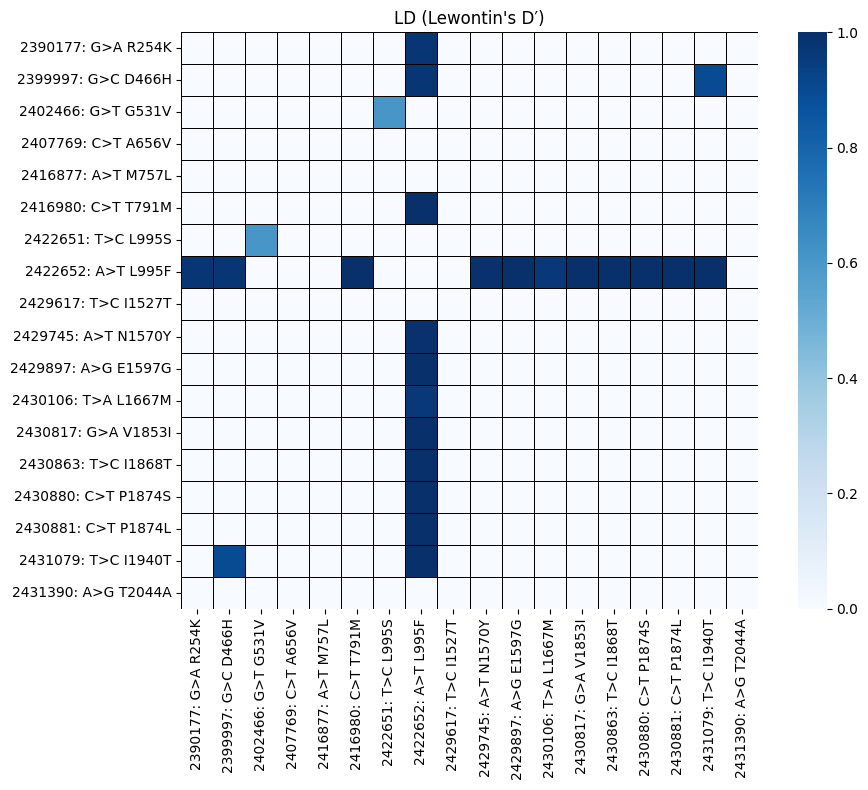

In [39]:
def plot_ld_with_gridspec(ld_df, title="LD (Lewontin's D′)"):
    n = ld_df.shape[0]

    # -------------------------------------------
    # 1. Setup GridSpec for the plot
    # -------------------------------------------
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(1, 1, figure=fig)

    ax = fig.add_subplot(gs[0, 0])

    # -------------------------------------------
    # 2. Draw the heatmap
    # -------------------------------------------
    sns.heatmap(
        ld_df,
        cmap="Blues",
        vmin=0, vmax=1,
        square=True,
        linewidths=0.5,        # visible gridlines!
        linecolor="black",     # gridline color
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )

    # -------------------------------------------
    # 3. Axis and title formatting
    # -------------------------------------------
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.tick_params(axis='both', which='major')

    plt.tight_layout()
    plt.show()


# Example usage:
plot_ld_with_gridspec(ld_df)
